<a href="https://colab.research.google.com/github/LuisPichal-52/Juegonuevo/blob/main/Datasetiris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Construyendo un clasificador con el dataset Iris.

--- Primeras 5 filas del dataset ---
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  

¡Modelo de Regresión Lineal entrenado con éxito!
--- Reporte de Rendimiento de la Regresión ---
Error Cuadrático Medio (MSE): 0.0456
Coeficiente de Determinación (R² Score): 92.83% (Qué tan bien se ajusta la línea)

Para una longitud de pétalo de 4.5 cm, el modelo predice un ancho de: **1.50 cm**


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


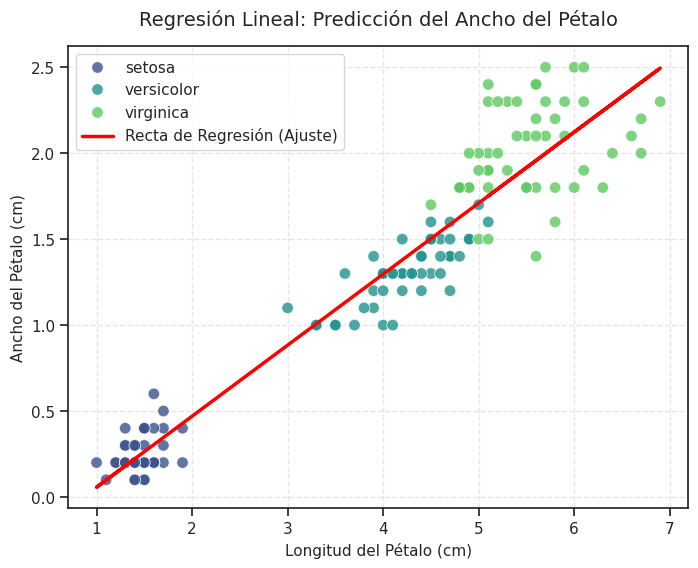

Ecuación de la recta: Ancho = 0.41 * Longitud + (-0.36)


In [2]:
# =====================================================================
# IMPORTACIONES Y CARGA DE DATOS
# =====================================================================
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="ticks")

# 1. Se carga el dataset Iris
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("--- Primeras 5 filas del dataset ---")
print(df.head())

# =====================================================================
# PREPROCESAMIENTO PARA REGRESIÓN LINEAL
# =====================================================================
# En regresión lineal no predecimos la especie, sino una variable continua.
# Vamos a usar la longitud del pétalo (X) para predecir el ancho del pétalo (y).
X_reg = df[['petal length (cm)']]  # Sklearn requiere matriz 2D para las X
y_reg = df['petal width (cm)']     # Variable continua a predecir

from sklearn.model_selection import train_test_split

# Dividimos en entrenamiento y prueba de la misma forma
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# =====================================================================
# ENTRENAR EL MODELO DE REGRESIÓN LINEAL
# =====================================================================
# Inicializar y entrenar el modelo de Regresión Lineal
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

print("\n¡Modelo de Regresión Lineal entrenado con éxito!")

# =====================================================================
# EVALUACIÓN DEL RENDIMIENTO
# =====================================================================
# Realizamos las predicciones numéricas con el conjunto de prueba
y_pred = model_lr.predict(X_test)

# Calculamos métricas de regresión en lugar de precisión de clasificación
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Reporte de Rendimiento de la Regresión ---")
print(f"Error Cuadrático Medio (MSE): {mse:.4f}")
print(f"Coeficiente de Determinación (R² Score): {r2 * 100:.2f}% (Qué tan bien se ajusta la línea)")

# =====================================================================
# PROBAR CON UN NUEVO EJEMPLO
# =====================================================================
# Si encontramos una flor cuyo pétalo mide 4.5 cm de largo... ¿cuánto medirá de ancho?
nueva_longitud = np.array([[4.5]])
prediccion_ancho = model_lr.predict(nueva_longitud)
print(f"\nPara una longitud de pétalo de 4.5 cm, el modelo predice un ancho de: **{prediccion_ancho[0]:.2f} cm**")

# =====================================================================
# CREAR LA GRÁFICA DE REGRESIÓN
# =====================================================================
plt.figure(figsize=(8, 6))

# 1. Dibujamos los puntos reales
sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species",
    palette="viridis",
    s=70,
    alpha=0.8
)

# 2. Dibujamos la recta de regresión que predice el modelo sobre todo el rango
# Usamos los datos originales de X para trazar la línea completa de extremo a extremo
plt.plot(
    df["petal length (cm)"],
    model_lr.predict(X_reg),
    color="red",
    linewidth=2.5,
    label="Recta de Regresión (Ajuste)"
)

# Añadir títulos y etiquetas
plt.title("Regresión Lineal: Predicción del Ancho del Pétalo", fontsize=14, pad=15)
plt.xlabel("Longitud del Pétalo (cm)", fontsize=11)
plt.ylabel("Ancho del Pétalo (cm)", fontsize=11)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

# Mostrar el gráfico en Colab
plt.show()

# Imprimir la ecuación matemática final generada
print(f"Ecuación de la recta: Ancho = {model_lr.coef_[0]:.2f} * Longitud + ({model_lr.intercept_:.2f})")